In [1]:
from pathlib import Path

path = Path("/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/06_training_data/training_03.h5")

print(path.exists())
print(path.stat().st_size / 1024**2, "MB")

True
925.6194267272949 MB


In [13]:
import h5py

path = "/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/06_training_data/training_03.h5"

with h5py.File(path, "r") as f:
    print(list(f.keys()))

['X', 'X_err', 'gaia_source_id', 'gaia_wavelength_nm', 'sdss_obj_id', 'sdss_wavelength_aa', 'y']


In [14]:
with h5py.File(path, "r") as f:
    print("X:", f["X"].shape)
    print("X_err:", f["X_err"].shape)
    print("X_id:", f["gaia_source_id"].shape)
    print("y:", f["y"].shape)
    print("y_id:", f["sdss_obj_id"].shape)
    print("gaia wavelengths:", f["gaia_wavelength_nm"].shape)
    print("sdss wavelengths:", f["sdss_wavelength_aa"].shape)

X: (55621, 343)
X_err: (55621, 343)
X_id: (55621,)
y: (55621, 3600)
y_id: (55621,)
gaia wavelengths: (343,)
sdss wavelengths: (3600,)


In [15]:
import numpy as np

with h5py.File(path, "r") as f:
    X = f["X"][:]
    X_err = f["X_err"][:]
    y = f["y"][:]

    gaia_wavelength = f["gaia_wavelength_nm"][:]
    sdss_wavelength = f["sdss_wavelength_aa"][:]
    X_id = f["gaia_source_id"][:]
    y_id = f["sdss_obj_id"][:]

print(X.shape)
print(y.shape)
print(X_id.shape)
print(y_id.shape)

(55621, 343)
(55621, 3600)
(55621,)
(55621,)


In [16]:
# Multiplicamos por 10 Gaia para estar en la misma escala de longitud de onda
gaia_wavelength = gaia_wavelength*10
# Convertimos las medidas de Gaia a la misma unidad que SDSS
X = X / 1e-19

# Nos quedamos solo con el intervalo común de ambos datos 
gaia_mask = (gaia_wavelength >= 5000) & (gaia_wavelength <= 9000)
sdss_mask = (sdss_wavelength >= 5000) & (sdss_wavelength <= 9000)

X = X[:, gaia_mask]
X_err = X_err[:, gaia_mask]

y = y[:, sdss_mask]
# Falta SNR de SDSS

gaia_wavelength = gaia_wavelength[gaia_mask]
sdss_wavelength = sdss_wavelength[sdss_mask]

print(X.shape)
print(y.shape)

(55621, 201)
(55621, 2666)


In [24]:
import numpy as np
import matplotlib.pyplot as plt

def plot_random_examples(
    X,
    y,
    gaia_wavelength,
    sdss_wavelength,
    gaia_ID,
    sdss_ID,
    n_examples=5,
    seed=None
):

    rng = np.random.default_rng(seed)
    n_samples = X.shape[0]

    random_indices = rng.choice(
        n_samples,
        size=min(n_examples, n_samples),
        replace=False
    )

    for idx in random_indices:
        plt.figure(figsize=(11, 5))

        plt.plot(
            sdss_wavelength,
            y[idx],
            label="Espectro observado por SDSS",
            linewidth=1.2
        )

        plt.plot(
            gaia_wavelength,
            X[idx],
            label="Espectro observado por Gaia",
            linewidth=1.2,
            alpha=0.8
        )

        plt.xlabel("Longitud de onda [Å]")
        plt.ylabel("Flujo")
        plt.title(
            f"Gaia source_id: {gaia_ID[idx]} | SDSS obj_id: {sdss_ID[idx]}"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return random_indices

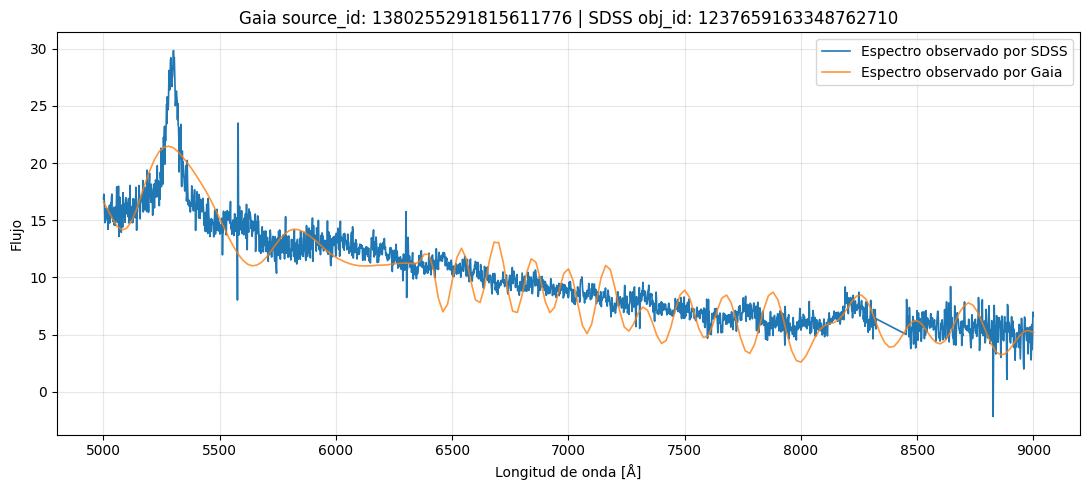

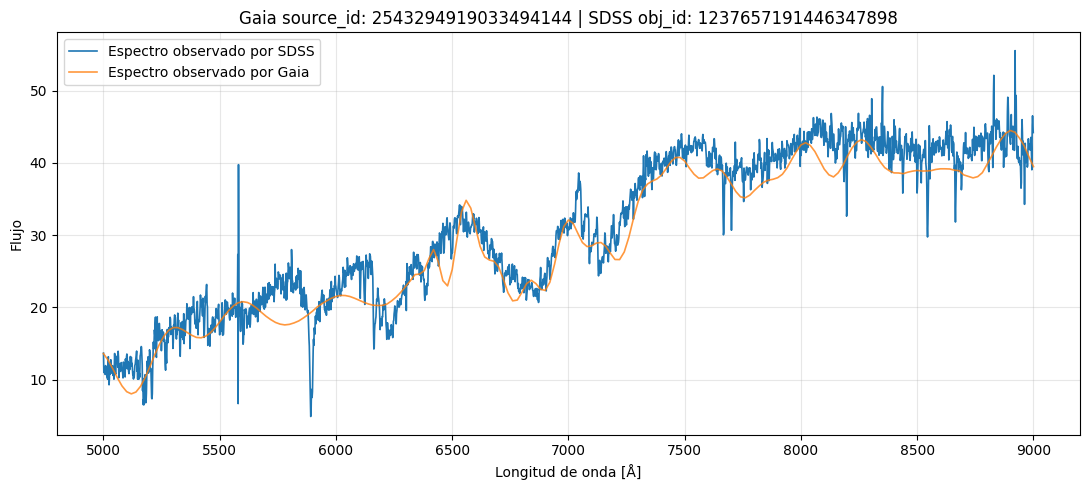

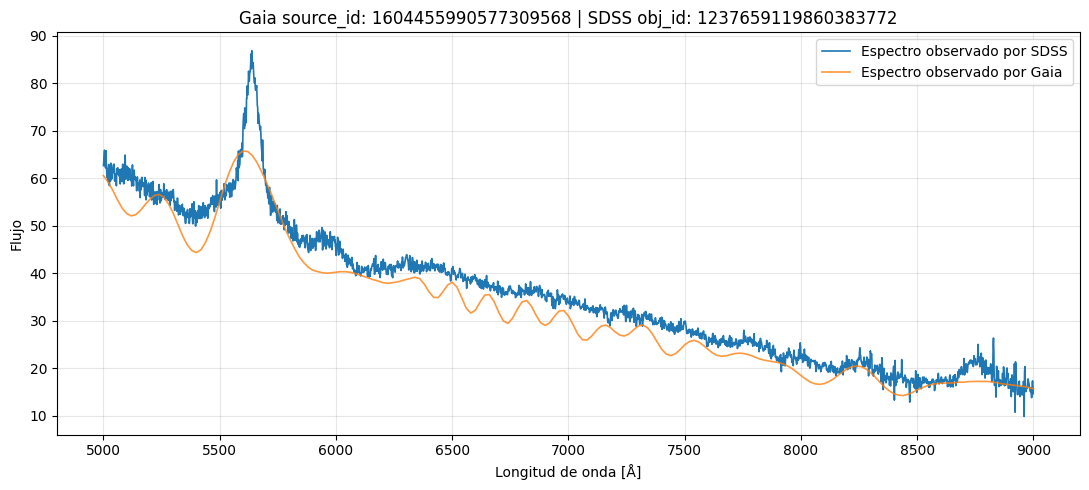

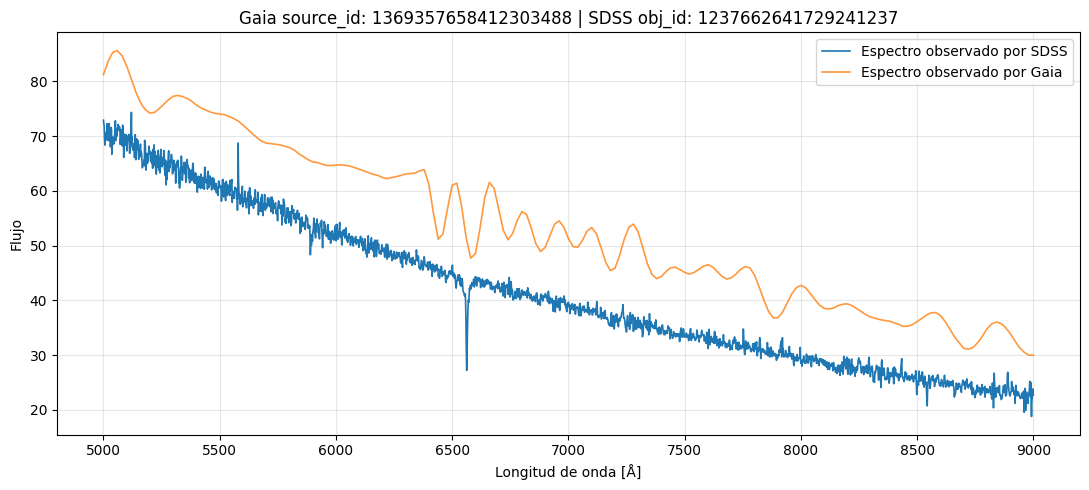

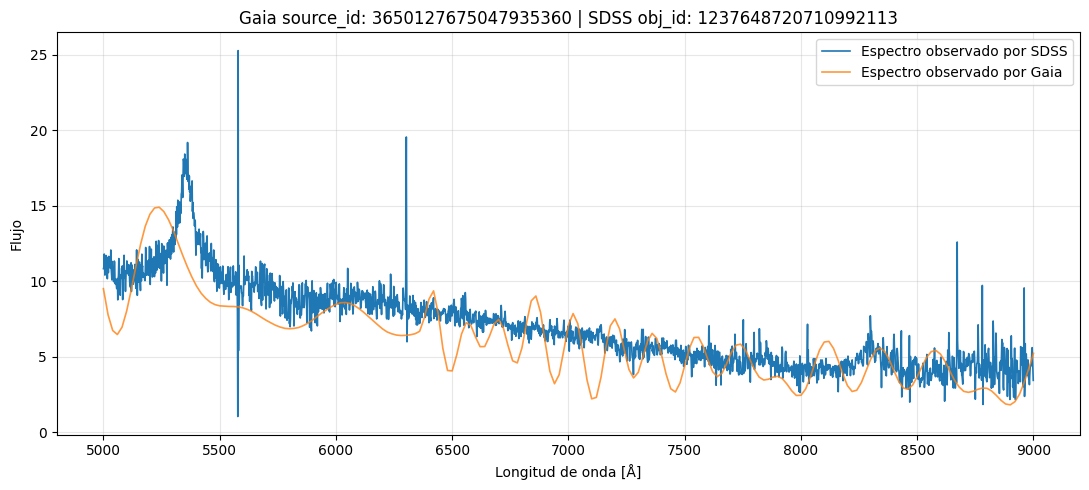

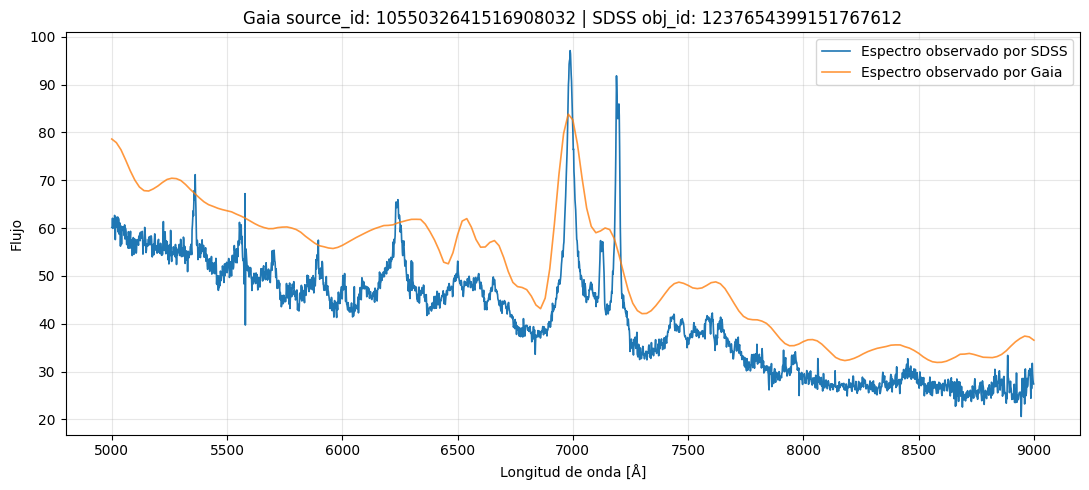

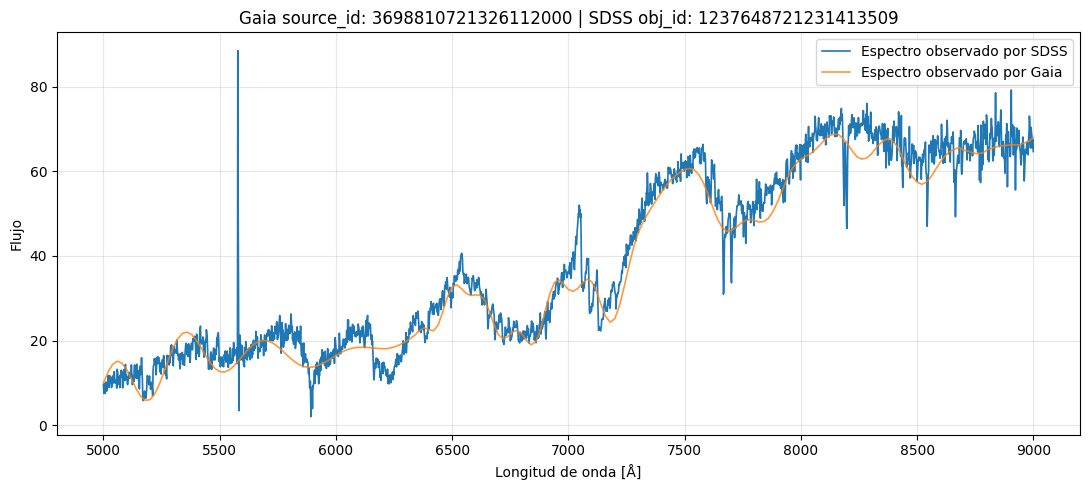

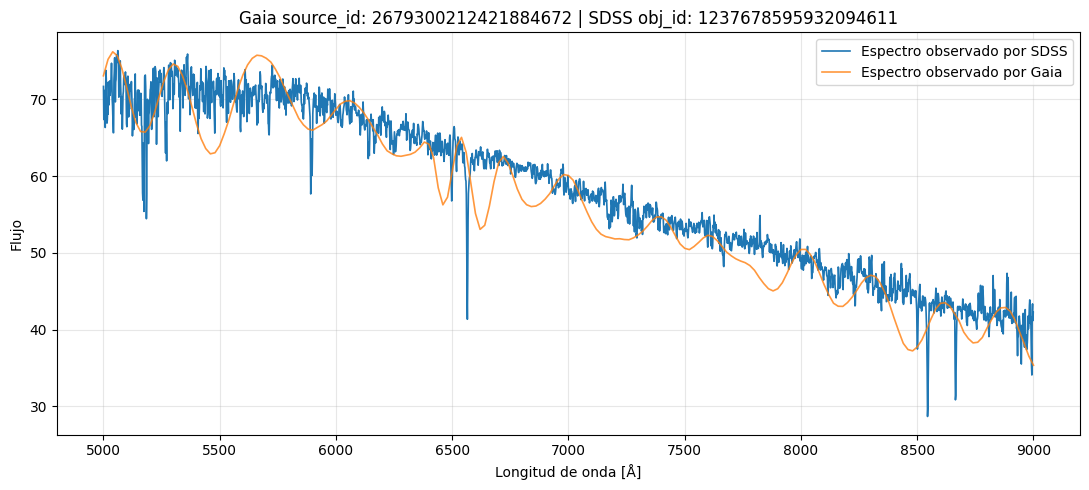

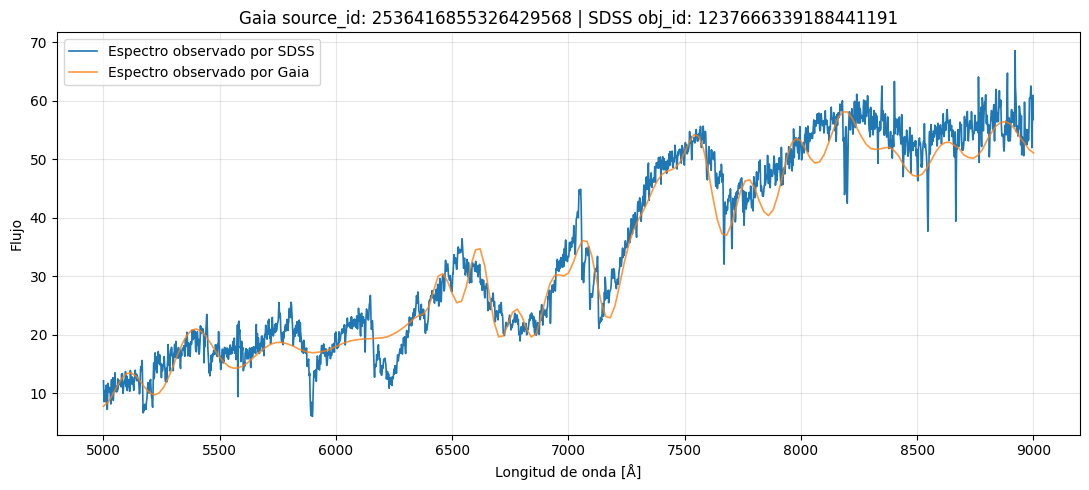

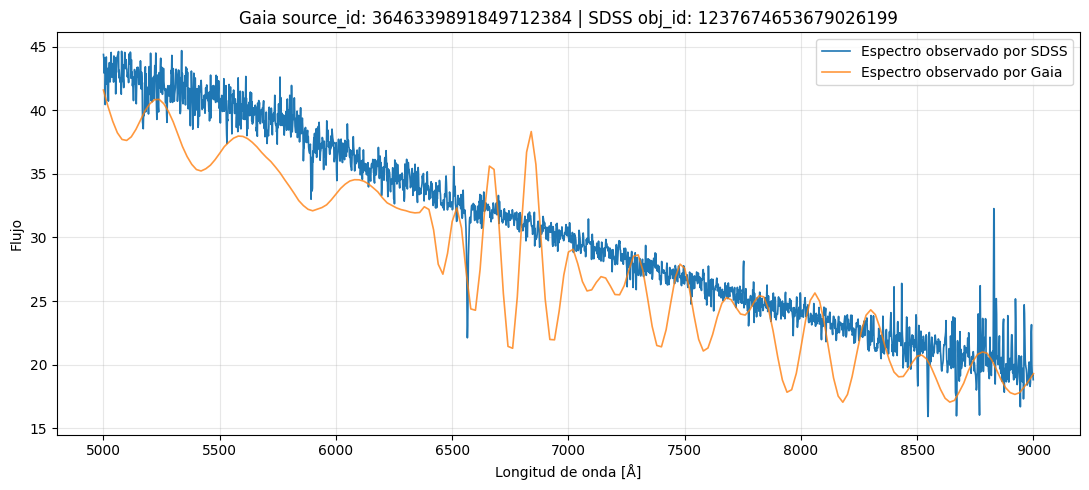

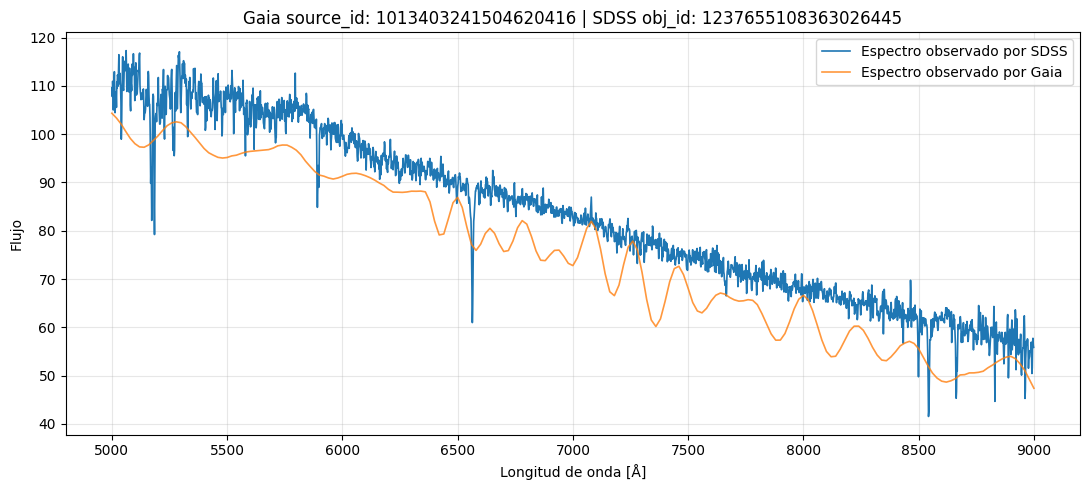

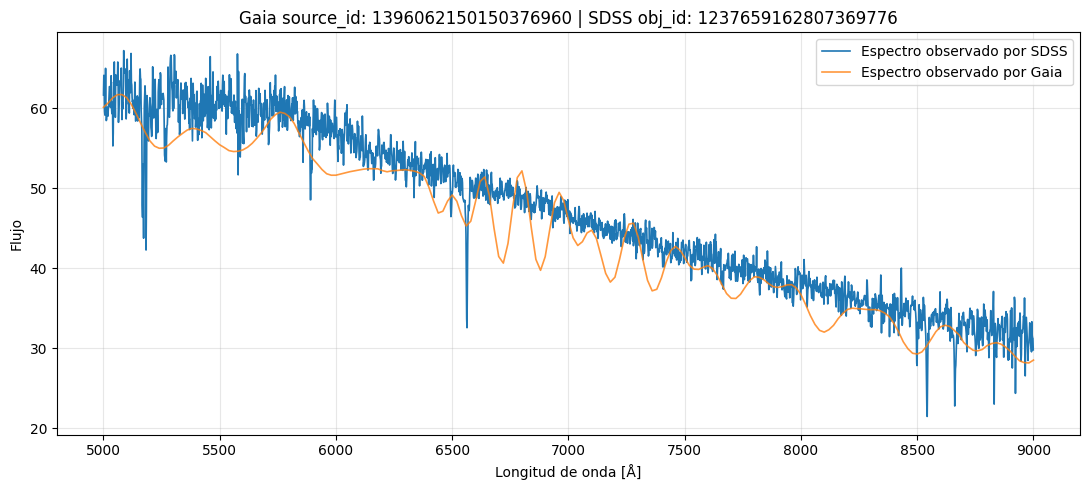

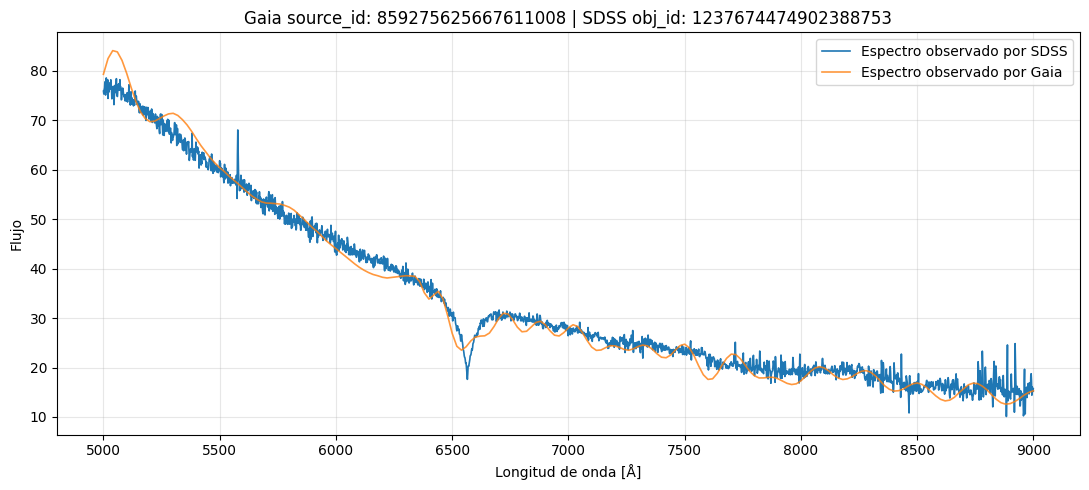

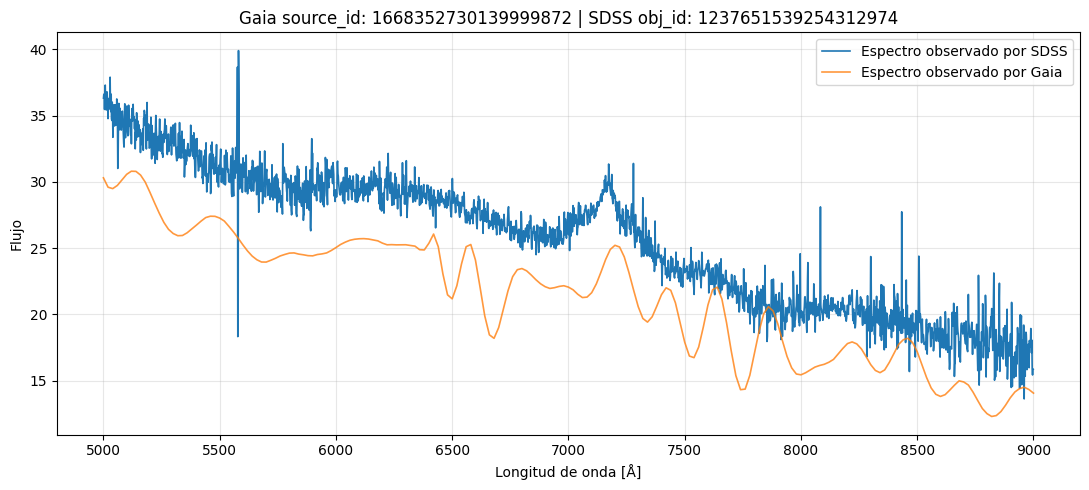

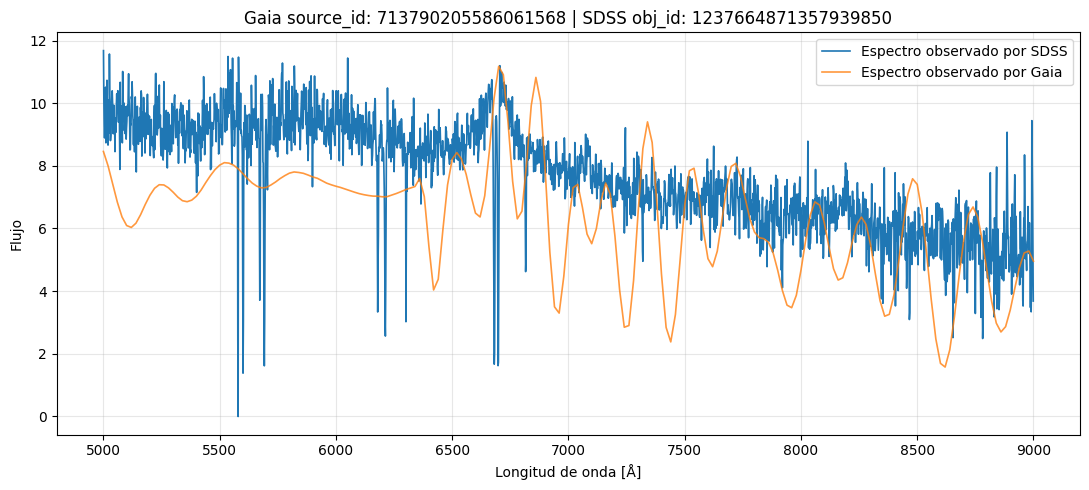

In [28]:
random_indices = plot_random_examples(
    X=X,
    y=y,
    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength,
    gaia_ID=X_id,
    sdss_ID=y_id,
    n_examples=15,
    seed=5 #2
)

In [29]:
# Calculamos la escala de los espectros
gaia_scale = np.nanmedian(np.abs(X), axis=1)
sdss_scale = np.nanmedian(np.abs(y), axis=1)

# Ratio Gaia / SDSS
scale_ratio = gaia_scale / (sdss_scale)

print(np.nanpercentile(scale_ratio, [0, 1, 2, 5, 10, 50, 90, 95, 98, 99, 100]))

[0.0256451  0.63751963 0.67069547 0.72489202 0.80475909 0.97298855
 1.25146067 1.40597987 1.54379449 1.82763968        nan]


/var/folders/39/1wfqcmsn0g5drvtznv_yzdhw0000gn/T/ipykernel_11705/504825443.py:6: RuntimeWarning: divide by zero encountered in divide
  scale_ratio = gaia_scale / (sdss_scale)
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


In [35]:
import numpy as np

X_model = X
y_model = y

finite_mask = (
    np.isfinite(X_model).all(axis=1)
    & np.isfinite(y_model).all(axis=1)
)

y_p1 = np.nanpercentile(y_model, 1, axis=1)
y_p99 = np.nanpercentile(y_model, 99, axis=1)
y_p5 = np.nanpercentile(y_model, 5, axis=1)
y_p95 = np.nanpercentile(y_model, 95, axis=1)
y_median = np.nanmedian(np.abs(y_model), axis=1) + 1e-8
y_difference5 = y_p95 - y_p5

y_dynamic_range = y_p99 - y_p1
y_relative_range = y_dynamic_range / y_median


X_p1 = np.nanpercentile(X_model, 1, axis=1)
X_p99 = np.nanpercentile(X_model, 99, axis=1)
X_p5 = np.nanpercentile(X_model, 5, axis=1)
X_p95 = np.nanpercentile(X_model, 95, axis=1)
X_median = np.nanmedian(np.abs(X_model), axis=1) + 1e-8
X_difference5 = X_p95 - X_p5

X_dynamic_range = X_p99 - X_p1
X_relative_range = X_dynamic_range / X_median

In [9]:
print(np.nanpercentile(y_median, [0, 1, 2, 5, 10, 50, 90, 95, 98, 99, 100]))

print(np.nanpercentile(y_difference5, [0, 1, 2, 5, 10, 50, 90, 95, 98, 99, 100]))

[9.99999994e-09 2.32202191e+00 4.20667629e+00 5.72647810e+00
 7.30792427e+00 4.13982620e+01 1.29891296e+02 1.64941925e+02
 2.01740402e+02 2.37652231e+02 5.67021191e+03]
[   0.            4.24971336    4.83444867    6.0330925     7.65894794
   27.92912245   92.13323593  127.33889771  183.89729919  229.7072649
 2249.87664795]


In [ ]:
# Por si lo necesitamos mas tarde (no creo)
valid = (
    finite_mask
    & (y_dynamic_range < np.percentile(y_dynamic_range, 99))
    & (y_relative_range < np.percentile(y_relative_range, 99))
    & (y_median < np.nanpercentile(y_median, 99))
    & (y_median > np.nanpercentile(y_median, 1))
    & (y_difference5 < np.nanpercentile(y_difference5, 99))
    & (y_difference5 > np.nanpercentile(y_difference5, 1))
    & (X_dynamic_range < np.percentile(X_dynamic_range, 99))
    & (X_relative_range < np.percentile(X_relative_range, 99))
    & (X_median < np.nanpercentile(X_median, 99))
    & (X_median > np.nanpercentile(X_median, 1))
    & (X_difference5 < np.nanpercentile(X_difference5, 99))
    & (X_difference5 > np.nanpercentile(X_difference5, 1))
    & (scale_ratio < np.nanpercentile(scale_ratio, 95))
    & (scale_ratio > np.nanpercentile(scale_ratio, 5))
)

In [36]:
valid = (
    finite_mask
    # Calidad del espectro SDSS objetivo
    & (y_dynamic_range < np.nanpercentile(y_dynamic_range, 99))
    & (y_median > np.nanpercentile(y_median, 1))
    & (y_median < np.nanpercentile(y_median, 99))
    & (y_difference5 > np.nanpercentile(y_difference5, 1))
    # Coherencia Gaia-SDSS
    & (scale_ratio > np.nanpercentile(scale_ratio[np.isfinite(scale_ratio)], 5))
    & (scale_ratio < np.nanpercentile(scale_ratio[np.isfinite(scale_ratio)], 95))
)

print("Antes:", X_model.shape[0])
print("Después:", valid.sum())

X_model = X_model[valid]
y_model = y_model[valid]

Antes: 55621
Después: 48839


In [38]:
X_id = X_id[valid]
X_err = X_err[valid]

y_id = y_id[valid]

In [39]:
from sklearn.model_selection import train_test_split

# Separamos en train y temp, luego el temp lo usaremos para separar en test y validation para que los espectros queden mezclados

X_temp, X_test, X_id_temp, X_id_test, X_err_temp, X_err_test, y_temp, y_test, y_id_temp, y_id_test = train_test_split(
    X_model,
    X_id,
    X_err,
    y_model,
    y_id,
    test_size=0.2,
    random_state=23,
    shuffle=True
)

X_train, X_val, X_id_train, X_id_val, X_err_train, X_err_val, y_train, y_val, y_id_train, y_id_val = train_test_split(
    X_temp,
    X_id_temp,
    X_err_temp,
    y_temp,
    X_id_temp,
    test_size=0.2,
    random_state=23,
    shuffle=True
)

In [44]:
# Guardamos los datos de entrenamiento para usarlos en otros archivos
import numpy as np
from pathlib import Path

split_dir = Path("solution/data/splits")
split_dir.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    split_dir / "processed_data.npz",

    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    X_id_train = X_id_train,
    X_id_val = X_id_val,
    X_id_test = X_id_test,
    X_err_train = X_err_train,
    X_err_val = X_err_val,
    X_err_test = X_err_test,

    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    y_id_train = y_id_train,
    y_id_val = y_id_val,
    y_id_test = y_id_test,

    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength
)


In [ ]:

# Normalizamos los datos
X_mean = X_train.mean()
X_std = X_train.std()

y_mean = y_train.mean()
y_std = y_train.std()

X_train_norm = (X_train - X_mean) / X_std
X_val_norm = (X_val - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std
y_test_norm = (y_test - y_mean) / y_std